# Results Notebook

This Notebook contains the code for generating all figures and tables in the paper, using raw results from the experimaestro workspace.

# Imports and Utils

In [8]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# use ACM style

FONT_SIZE = 14
fig_dir = Path("./local/figures/mice")
# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
# 1. Configure Matplotlib for ACM Style
plt.rcParams.update(
    {
        "text.usetex": False,  # Set to True if you have LaTeX installed on your system
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
        "font.size": 10,  # Standard ACM body text size is ~9-10pt
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)
plt.style.use("ggplot")


# default_workspace_path
# ws = get_workspace().path
# xps_root = ws / "experiments"

xps_root = Path("/Users/victor/code/experiments/JZ")


def get_last_xp(xp_id, force_date=None) -> str:
    dates = sorted(list((xps_root / xp_id).glob("*")))
    print(f"Found dates for {xp_id}: {[d.name for d in dates]}")

    # parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            print(f"Using forced date for {xp_id}: {forced_date_path.name}")
            return forced_date_path
        else:
            print(f"Forced date {force_date} not found for xp {xp_id}")

    dates = [d for d in dates if re.match(r"\d+_\d+", d.name)]

    last = "" 
    # last = max(dates, key=lambda d: d.name)
    for date in dates[::-1]:
        if (xps_root / xp_id / date / "results" / "results.csv").exists():
            last = date
            break


    if not last:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        last = "dry-run"

    return xps_root / xp_id / last


def get_results(xp_path) -> pd.DataFrame:
    path = xp_path / "results"
    csv_files = list(path.glob("results.csv"))

    if len(csv_files):
        return pd.read_csv(csv_files[0])
    else:
        raise ValueError(f"no csv files found in {path}")


def process_results(results) -> pd.DataFrame:
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    labels[0] = "dataset"
    results.columns = labels
    results = results.iloc[2:]
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    # results[cols_to_convert] = results[cols_to_convert].apply(
    #     pd.to_numeric, errors="coerce"
    # )

    return results


def get_aggregated_stats(results, group_cols, metrics):
    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f"{m}_mean", f"{m}_var"])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors="coerce")

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f"{m}_mean"] = f"{m}_Grand_Mean"
        rename_dict[f"{m}_var"] = f"{m}_Average_Var"

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)

    return aggregated_stats
    # Add experiment label


def get_aggregated_df(df, datasets, name):
    """
    Returns a NEW DataFrame with aggregated means for specific datasets.
    Does not modify the original df.
    """
    # 1. Identify metric columns and metadata columns
    metric_cols = df.filter(regex="(?i)mean|var").columns.tolist()
    # Metadata columns are everything EXCEPT the metrics and the dataset name
    metadata_cols = [c for c in df.columns if c not in metric_cols and c != "dataset"]

    # 2. Filter rows for the specified datasets
    subset = df[df["dataset"].isin(datasets)].copy()
    subset[metric_cols] = subset[metric_cols].apply(pd.to_numeric, errors="coerce")

    # 3. Group by ALL metadata columns to preserve them
    # This keeps 'base', 'loss', 'scorer', 'arch', etc. intact
    new_df = subset.groupby(metadata_cols, as_index=False)[metric_cols].mean()

    # 4. Assign the new dataset aggregate name
    new_df["dataset"] = name

    # Reorder for readability: dataset first, then metadata, then metrics
    cols = ["dataset"] + metadata_cols + metric_cols
    return new_df[cols]


print(f"found xps in {xps_root}")
all_xps = list(xps_root.glob("*"))
for xp in sorted(all_xps):
    print(f"- {xp.name}")

found xps in /Users/victor/code/experiments/JZ
- baseline_MiniLM_CE
- baseline_mores
- baseline_small_CE
- baseline_small_CE_withruns
- colbertNeg_base
- colbertNeg_infoNCE_precision
- colbertNeg_mini
- comparison_precision
- core_base
- core_base_deberta
- core_base_deberta_top100
- core_base_ettin
- core_base_ettin_1b
- core_base_ettin_1b_bs=16
- core_base_ettin_scaling
- core_base_ettin_scaling_except_1b
- core_base_paper
- core_mini
- core_mini_debug
- cross_scorer_evaluation
- cross_scorer_evaluation_debug
- debug_CE_training
- debug_mice_plaid
- debug_mice_training
- eval_masked_step0
- eval_scorer_debug
- eval_scorer_top100
- eval_scorer_top1000
- hyperparams_search_contrastive
- local_model_evaluation
- reproduction_RankDistiLLM
- train_mice_ettin68_lX+3
- train_mice_ettin_150m
- train_mice_ettin_17m
- train_mice_ettin_32m
- train_mice_ettin_68m
- train_mice_miniLM
- train_mice_miniLM_L4_abl_bounded
- train_mice_miniLM_L4_abl_bsize
- train_mice_miniLM_L8_abl_loss
- train_mice_m

### Labeling

In [2]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

ignore_losses = ["infoNCE_norm_size=True"]

/Users/victor/code/projects/cross-encoders/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Main Results 

## Mice-$\ell$ Y+X

### Loading

In [3]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_l4+X": r"Mice MiniLM-$\ell$4+X",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_l4+X: ['20260511_190322', '20260512_104628', '20260512_105439', '20260512_110152', '20260512_221517', 'current', 'dry-run', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_l4+X/20260512_221517
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_interaction_layers
2,In Domain,0.620067,NaN,0.716733,NaN,0.405833,NaN,0.405767,NaN,NaN,bm25,NaN
3,In Domain,0.756756,0.000010,0.826467,1.816459e-05,0.613600,1.067686e-06,0.602756,2.870410e-07,microsoft/MiniLM-L12-H384-uncased,bm25,1
4,In Domain,0.753378,0.000004,0.833944,1.078783e-04,0.616911,7.407074e-06,0.607122,9.959185e-07,microsoft/MiniLM-L12-H384-uncased,bm25,2
5,In Domain,0.764144,0.000004,0.844133,1.386999e-05,0.625155,6.781769e-07,0.611256,5.747773e-07,microsoft/MiniLM-L12-H384-uncased,bm25,3
6,In Domain,0.763533,0.000002,0.846745,5.514589e-07,0.624856,9.206986e-06,0.613400,2.063339e-06,microsoft/MiniLM-L12-H384-uncased,bm25,4


### Plotting

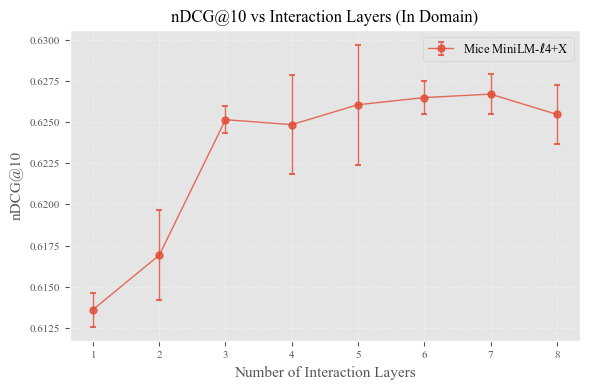

In [4]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
y_key = "n_interaction_layers"

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(6, 4))

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df[y_key] = pd.to_numeric(df[y_key], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df[y_key].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_interaction_layers and compute aggregated statistics
        grouped = dataset_df.groupby(y_key, dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values(y_key)

        ax.errorbar(
            grouped[y_key],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=5,
            linewidth=1,
            capsize=2,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]}"
        )

    # Formatting
    ax.set_xlabel("Number of Interaction Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Interaction Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped[y_key].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_InteractionLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
    # print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    # display(grouped)

## Mice X+3

### Loading

In [21]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Mice MiniLM-lX+3",
    "train_mice_ettin68_lX+3": "Mice Ettin-68m-lX+3",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3/20260513_093201
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
2,In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN
3,In Domain,0.7280777,1.4114847e-06,0.8224667,1.3663354e-05,0.55876666,6.601004e-06,0.5579445,1.0670453e-06,microsoft/MiniLM-L12-H384-uncased,bm25,0
4,In Domain,0.7379778,1.9640476e-05,0.82625556,2.223799e-06,0.58382225,9.971361e-06,0.5800333,4.407645e-06,microsoft/MiniLM-L12-H384-uncased,bm25,1
5,In Domain,0.75412226,3.973603e-06,0.84076667,6.300482e-07,0.60194445,1.1077915e-05,0.59511113,7.071646e-06,microsoft/MiniLM-L12-H384-uncased,bm25,2
6,In Domain,0.7584222,9.2294285e-06,0.83955556,1.4446058e-05,0.61396664,1.1811496e-06,0.60326666,1.8777122e-07,microsoft/MiniLM-L12-H384-uncased,bm25,3


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin68_lX+3: ['20260513_093057', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin68_lX+3/20260513_093057
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
2,In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN
3,In Domain,0.7000889,4.2071283e-06,0.7921445,1.2504692e-05,0.5251222,4.0226373e-06,0.52088886,1.8993629e-05,jhu-clsp/ettin-encoder-68m,bm25,0
4,In Domain,0.71996665,5.1029754e-05,0.81402224,1.3262507e-05,0.58115554,6.4148e-07,0.5756555,2.0038112e-07,jhu-clsp/ettin-encoder-68m,bm25,1
5,In Domain,0.7659888,8.1802755e-06,0.84086674,1.2754607e-05,0.62788886,4.6958585e-06,0.61905557,1.1603523e-06,jhu-clsp/ettin-encoder-68m,bm25,10
6,In Domain,0.7658667,1.7967714e-05,0.8438444,7.705554e-08,0.6301778,4.692238e-07,0.6233889,1.0670453e-06,jhu-clsp/ettin-encoder-68m,bm25,11


### Plotting


Aggregated nDCG@10 Statistics by Contextualization Layers (In Domain):


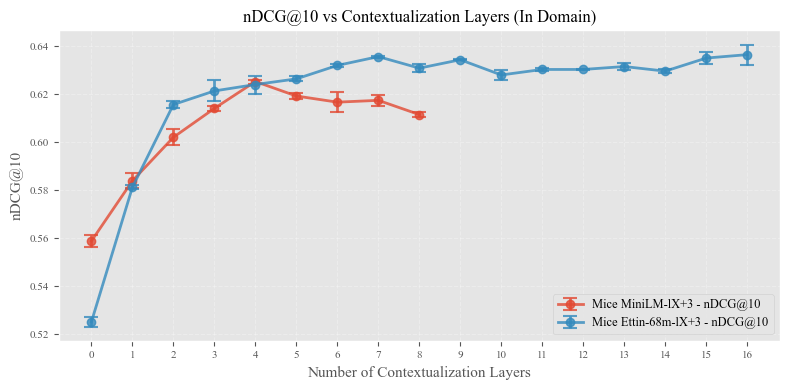

In [23]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
figsize=(8, 4)

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=figsize)

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")

        ax.errorbar(
            grouped["n_contextualization_layers"],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=6,
            linewidth=2,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]} - {metric}"
        )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
        # display(grouped)

# Table Mice Results


In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_ettin_68m": "Mice-Ettin-68m-l8+3",
    "train_mice_ettin_32m": "Mice-Ettin-68m-l8+3",
    # "train_mice_ettin_150m": "test",
    "train_mice_miniLM_l4": "Mice-MiniLM-l4+3",
    "baseline_small_CE": "Baseline",
}
models = []

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_68m: ['20260428_104550', '20260429_150119', '20260429_150645', '20260430_110052', '20260504_101003', '20260504_184231', '20260505_113253', '20260512_190001', '20260512_191723', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723
20 unique datasets : ['BEIR13', 'In Domain', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid']
Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_32m: ['20260409_174423', '20260409_195657', '20260513_085546', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin_32m/20260513_085546
20 unique datasets : ['BEIR13', 'In Domain', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq',

In [ ]:
metric = 
aggregations["BEIR13"]

['arguana',
 'climate_fever',
 'dbpedia',
 'fever',
 'fiqa',
 'hotpotqa',
 'nfcorpus',
 'nq',
 'quora',
 'scidocs',
 'scifact',
 'touche',
 'trec_covid']

## Pareto front

In [ ]:
from dataclasses import dataclass

@dataclass
class ModelResults:
    name: str

    path: Path
    """path to the model directory inf HF format"""

    results: pd.DataFrame = None
    """Results dataframe"""

    benchmark: dict = None
    """Performance benchmark"""

def get_models(xp_path) -> pd.DataFrame:
    path = xp_path / "results" / "models"
    #list directory and find csv files
    models = []

    model_dirs = [d for d in path.glob("*") if d.is_dir()]
    print(f"Found model directories in {path}: {[d.name for d in model_dirs]}")

    for model_dir in model_dirs:   
        csv_file = model_dir / "results.csv"
        if not csv_file.exists():
            print(f"Expected csv file not found in {model_dir}")
            continue
        else:
            models.append(
                ModelResults(
                    name=model_dir.name,
                    path=model_dir,
                    results=pd.read_csv(csv_file)
                )
            )
    return models

def process_results(results) -> pd.DataFrame:
    labels1 = results.iloc[0]
    labels2 = results.iloc[1]
    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    labels[0] = "dataset"
    results.columns = labels
    results = results.iloc[2:]
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    # Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results


In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_ettin_68m": "Mice-Ettin-68m-l8+3",
    "train_mice_ettin_32m": "Mice-Ettin-68m-l8+3",
    # "train_mice_ettin_150m": "test",
    "train_mice_miniLM_l4": "test",
    "baseline_small_CE": "test",
}
models = []

for xp in xps.keys():
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    
    models += get_models(xp_path)

for model in models:
    print()
    print(model.path.name)
    print(model.path)
    print(f"- evals on: {', '.join(model.results['dataset'].unique())}")


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_68m: ['20260428_104550', '20260429_150119', '20260429_150645', '20260430_110052', '20260504_101003', '20260504_184231', '20260505_113253', '20260512_190001', '20260512_191723', 'current', 'dry-run']
Found model directories in /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models: ['Mice-l8+3-ettin-68m']
Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_32m: ['20260409_174423', '20260409_195657', '20260513_085546', 'current', 'dry-run']
Found model directories in /Users/victor/code/experiments/JZ/train_mice_ettin_32m/20260513_085546/results/models: ['Mice-l6+3-ettin-32m']
Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_l4: ['20260422_162656', '20260425_233137', '20260425_233707', '20260504_182944', '20260505_113202', 'current', 'dry-run']
Found model directories in /Users/victor/code/experiments/JZ/train_mice_miniLM_l4/20260505_113202/results/models: ['

In [ ]:
from xpm_torch.huggingface import TorchHFHub 
from profiling_utils import benchmark_model
from xpmir.letor.records import PointwiseItems
import os
os.environ["HF_HUB_OFFLINE"]= "1"

# batch = DummyBatch.build(batch_size=4, query="What is AI?", document="AI stands for Artificial Intelligence.")
batch_size = 16
queries = ["What is the capital of France?"]
documents = ["Paris is the capital and most populous city of France." * 100] * batch_size
input_records = PointwiseItems.from_texts(topics=queries, documents=documents)

for model in models:
    model.benchmark = benchmark_model(
        model_name_or_path=model.path,
        batch=input_records,
        num_runs=20,
        print_model_summary=True,
    )


INFO:profiling_utils:--- Benchmarking Mice-l8+3-ettin-68m ---
config.json not found in /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models/Mice-l8+3-ettin-68m
INFO:xpmir.rankers.scorer:Initializing ModernBertMiceCrossEncoder
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/mai

[warn] CUDA not available, running on CPU may be slow.
ModernBertMiceCrossEncoder(
  (rotary_emb): ModernBertRotaryEmbedding()
  (embeddings): ModernBertEmbeddings(
    (tok_embeddings): Embedding(50368, 512, padding_idx=50283)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (bottom_layers): ModuleList(
    (0): ModernBertEncoderLayer(
      (attn_norm): Identity()
      (attn): ModernBertAttention(
        (Wqkv): Linear(in_features=512, out_features=1536, bias=False)
        (Wo): Linear(in_features=512, out_features=512, bias=False)
        (out_drop): Identity()
      )
      (mlp_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): ModernBertMLP(
        (Wi): Linear(in_features=512, out_features=1536, bias=False)
        (act): GELUActivation()
        (drop): Dropout(p=0.0, inplace=False)
        (Wo): Linear(in_features=768, out_features=512, bias=False)
      )
    )
    (1-7): 7 x ModernBer

INFO:profiling_utils:--- Benchmarking Mice-l6+3-ettin-32m ---
config.json not found in /Users/victor/code/experiments/JZ/train_mice_ettin_32m/20260513_085546/results/models/Mice-l6+3-ettin-32m
INFO:xpmir.rankers.scorer:Initializing ModernBertMiceCrossEncoder
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-32m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-32m/1b8ba06455dd44f80fc9c1ca9e22806157a57379/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-32m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-32m/1b8ba06455dd44f80fc9c1ca9e22806157a57379/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-32m/resolve/mai

FileNotFoundError: Could not find model weights at /Users/victor/code/experiments/JZ/train_mice_ettin_32m/20260513_085546/results/models/Mice-l6+3-ettin-32m/model.safetensors

['Mice-l4+3-MiniLM-L12-MarginMSE', 'cross-encoder-MiniLM-L12', 'cross-encoder-ettin-68m']


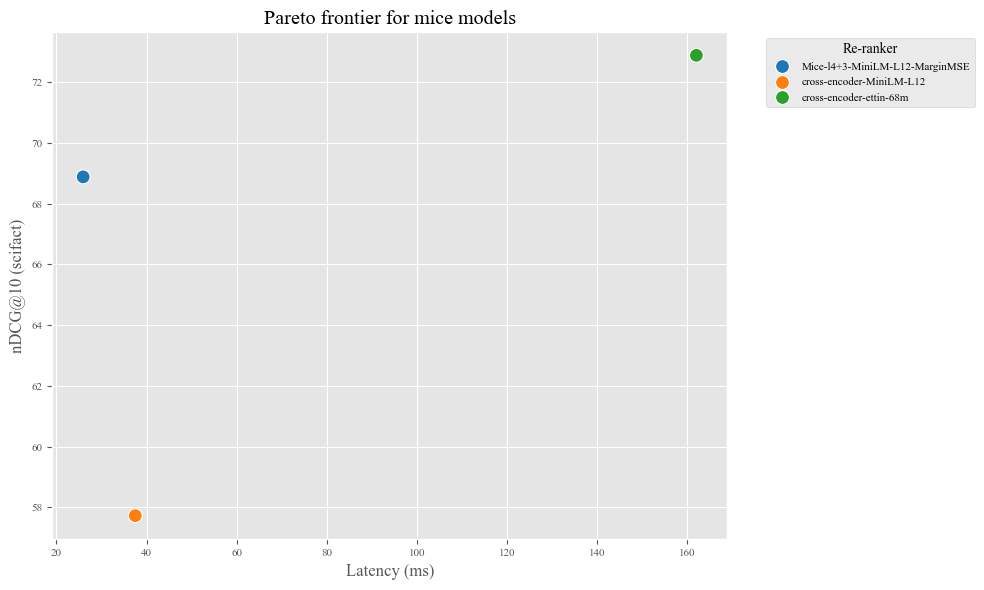

In [ ]:
metric_key = "nDCG@10"
dataset_y = "BEIR13"
dataset_y = "minified"
dataset_y = "scifact"

bench_key = "mean_time"
labels, perfs, costs = [] , [] , []
#plot performance so see correlation between performance on minified and beir13
for model in models: 
    labels.append(model.name)
    perfs.append(model.results.loc[model.results["dataset"] == dataset_y, metric_key].item())
    costs.append(model.benchmark[bench_key] * 1e3) # ms

print(labels)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=costs,
    y=perfs,
    hue=labels,
    palette="tab10",
    s=100,
    ax=ax,
)
ax.set_xlabel(f"Latency (ms)")
ax.set_ylabel(f"{metric_key} ({dataset_y})")
ax.set_title(f"Pareto frontier for mice models")
plt.legend(title="Re-ranker", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"./local/figures/mice/Pareto_frontier.pdf")
plt.show()

# Analysis

## Distribution of ndcg for Mice-$\ell4$+3 v Mice-$\ell8$+3

In [16]:
# Main table
import pandas as pd

xps = [
    "train_mice_miniLM_l4|8_ID_withruns",
    "baseline_small_CE_withruns",
    ]

for xp in xps:
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    xp_path = xps_root / xp / "dry-run"
    print(f"Using xp path: {xp_path}")
    xp_df = process_results(get_results(xp_path))

    datasets = xp_df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(xp_df['loss'].unique())}")
    # print(f"Backbones : {list(xp_df['base'].unique())}")
    display(xp_df.head())
# get dat files



Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_l4|8_ID_withruns: ['20260511_185945', '20260512_101811', '20260512_104719', '20260512_145819', 'current', 'dry-run', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_l4|8_ID_withruns/dry-run
7 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'nfcorpus', 'touche', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
2,In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN
3,In Domain,0.7633833,4.4004837e-06,0.8430833,2.1125037e-05,0.62553334,5.0001694e-07,0.61083335,8.002655e-08,microsoft/MiniLM-L12-H384-uncased,bm25,4
4,In Domain,0.76463336,1.5679863e-05,0.84188336,1.6058632e-07,0.61196667,7.199528e-07,0.6076833,4.6722363e-07,microsoft/MiniLM-L12-H384-uncased,bm25,8
5,mean,0.62522,NaN,0.73968,NaN,0.39485997,NaN,0.38708,NaN,NaN,bm25,NaN
6,mean,0.69496,1.7522982e-05,0.80619,3.040964e-07,0.50769997,2.5087381e-06,0.49431002,4.8020456e-07,microsoft/MiniLM-L12-H384-uncased,bm25,4


Found dates for /Users/victor/code/experiments/JZ/baseline_small_CE_withruns: ['20260512_214457', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/baseline_small_CE_withruns/dry-run
6 unique datasets : ['mean', 'msmarco_dev', 'nfcorpus', 'touche', 'trec2019', 'trec2020']


,dataset,nan,nan_bm25,mean_0.62006664,var,mean_0.7167333,var,mean_0.40583333,var,mean_0.40576664,var
2,mean,NaN,bm25,0.62522,NaN,0.73968,NaN,0.39485997,NaN,0.38708,NaN
3,msmarco_dev,NaN,bm25,0.1859,NaN,0.2941,NaN,0.2302,NaN,0.2546,NaN
4,nfcorpus,NaN,bm25,0.5236,NaN,0.6502,NaN,0.3202,NaN,0.294,NaN
5,touche,NaN,bm25,0.7423,NaN,0.898,NaN,0.4366,NaN,0.4241,NaN
6,trec2019,NaN,bm25,0.8349,NaN,0.9302,NaN,0.5107,NaN,0.4918,NaN


In [17]:

dat_files = xp_path.glob("results/models/*/evals/*.dat")
runs_per_model = {}

def parse_reranker_results(file_path_or_string):
    """
    Parses a reranker result file into a pandas DataFrame.
    The file is expected to have columns: Metric, QID, Score.
    """
    # Use sep='\s+' to handle multiple spaces or tabs
    # We define the column names manually as the file has no header
    df = pd.read_csv(
        file_path_or_string, 
        sep=r'\s+', 
        names=['Metric', 'QID', 'Score'], 
        header=None
    )
    return df

for dat in dat_files:
    model_name = dat.parent.parent.name
    dataset_name = re.match(r"detailed_(.+).dat", dat.name).group(1)
    runs = runs_per_model.get(model_name,{})
    runs[dataset_name] = parse_reranker_results(dat)
    runs_per_model[model_name] = runs

runs_per_model = {k:v for k,v in runs_per_model.items() if len(v.keys())}
models = list(runs_per_model.keys())
datasets = list(runs_per_model[models[0]].keys())
print(f"got runs for models: {models}")
display(runs_per_model[models[0]]["trec2019"])

IndexError: list index out of range

distribution for nfcorpus


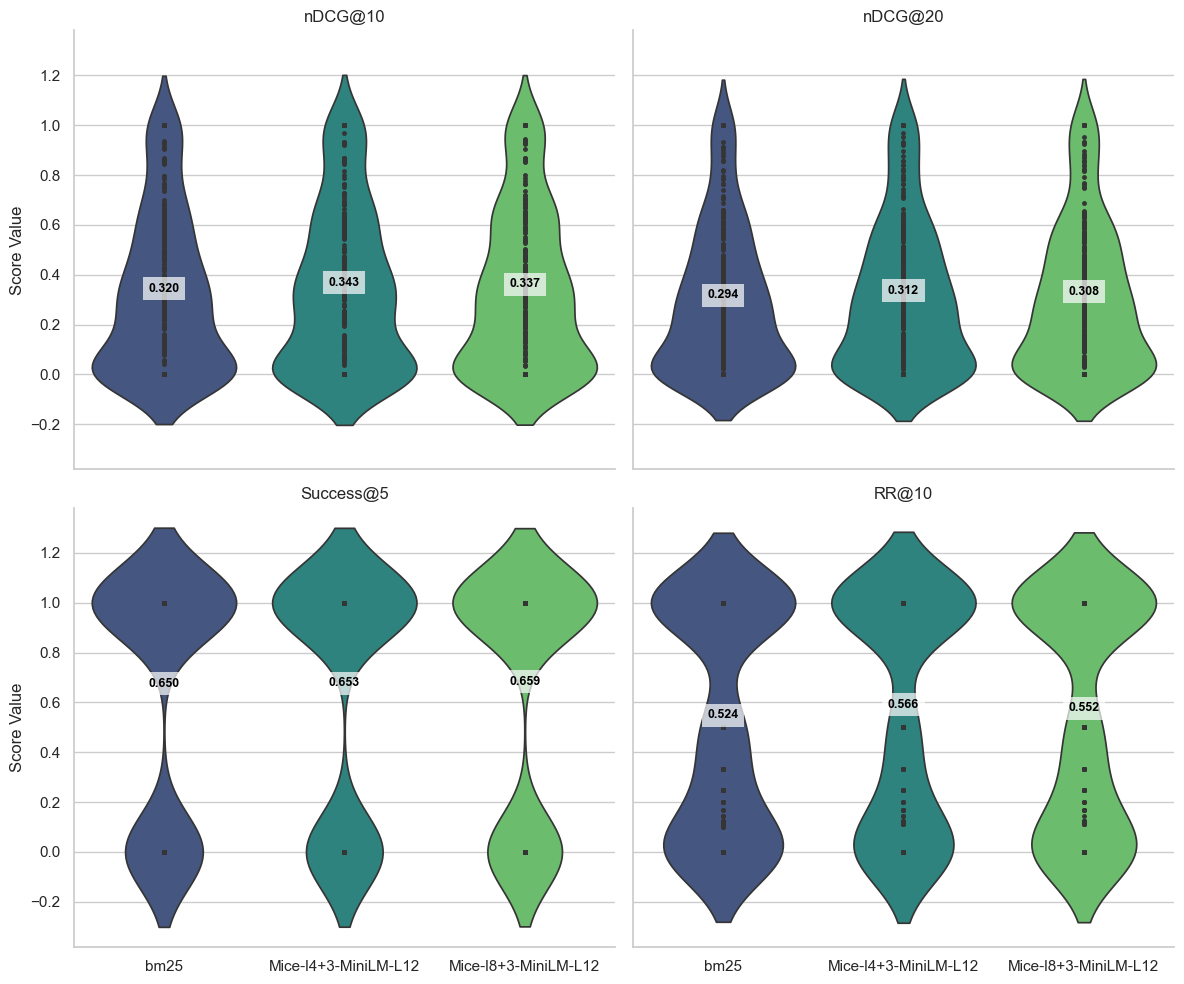

distribution for trec2019


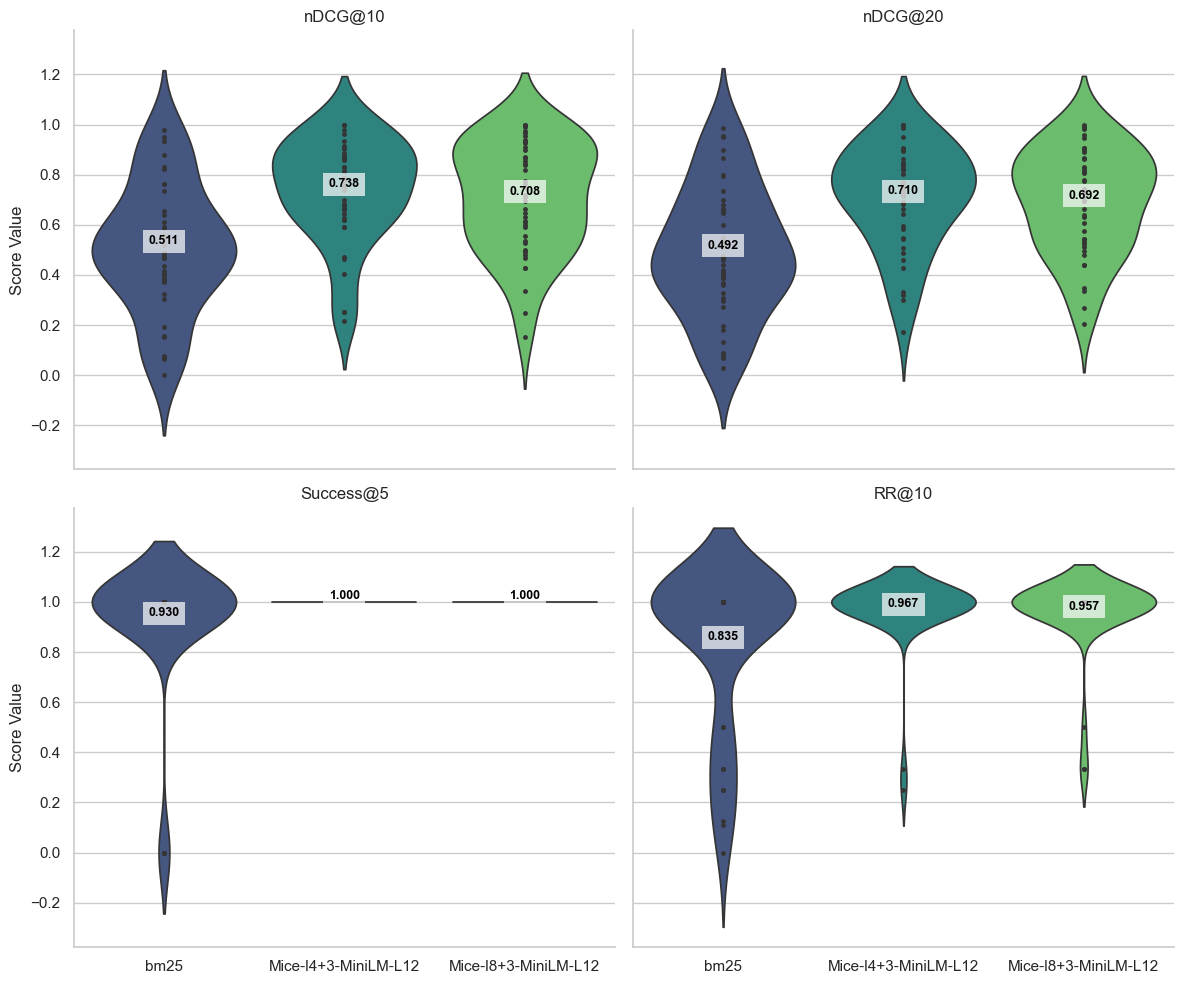

distribution for touche


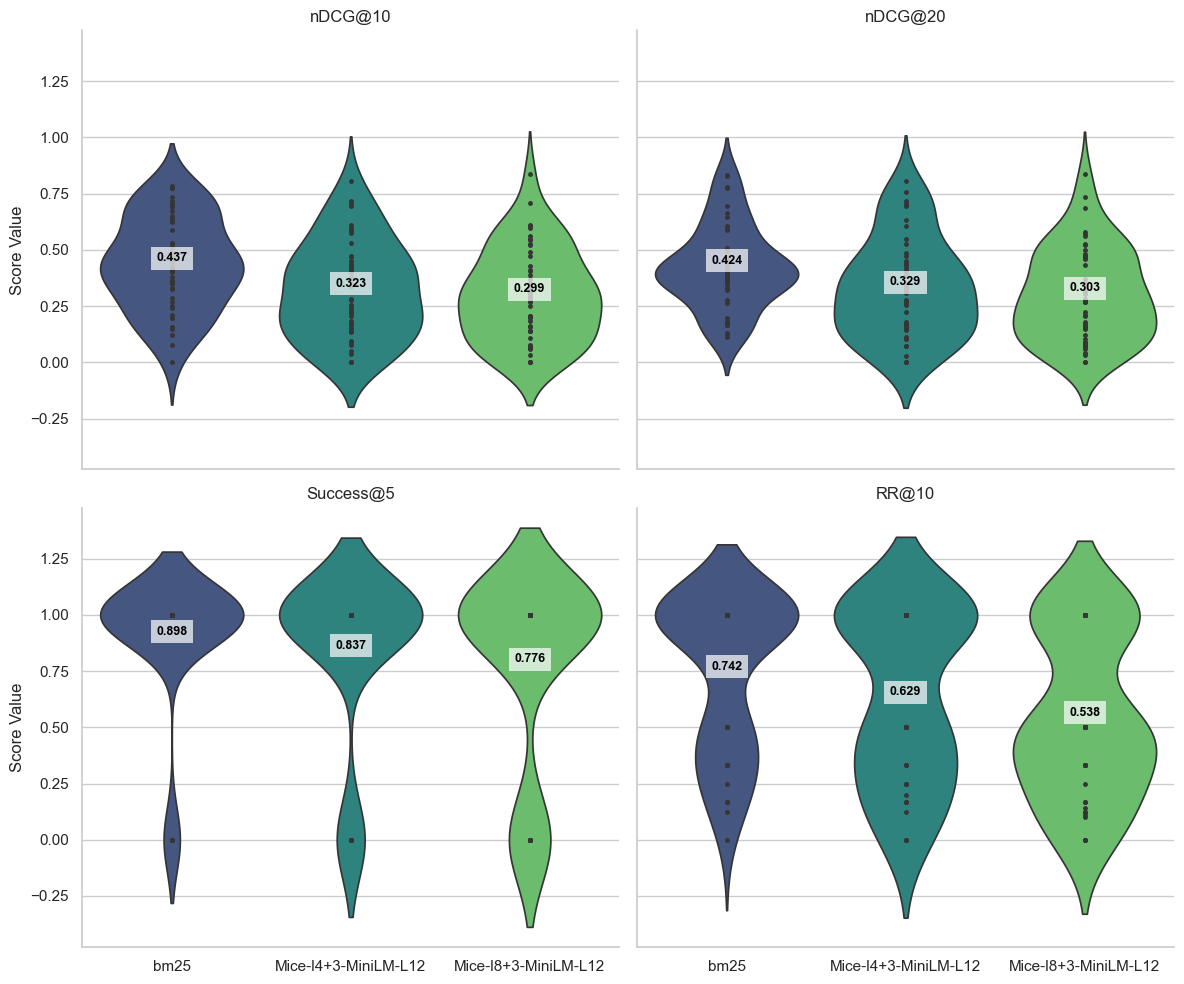

distribution for trec2020


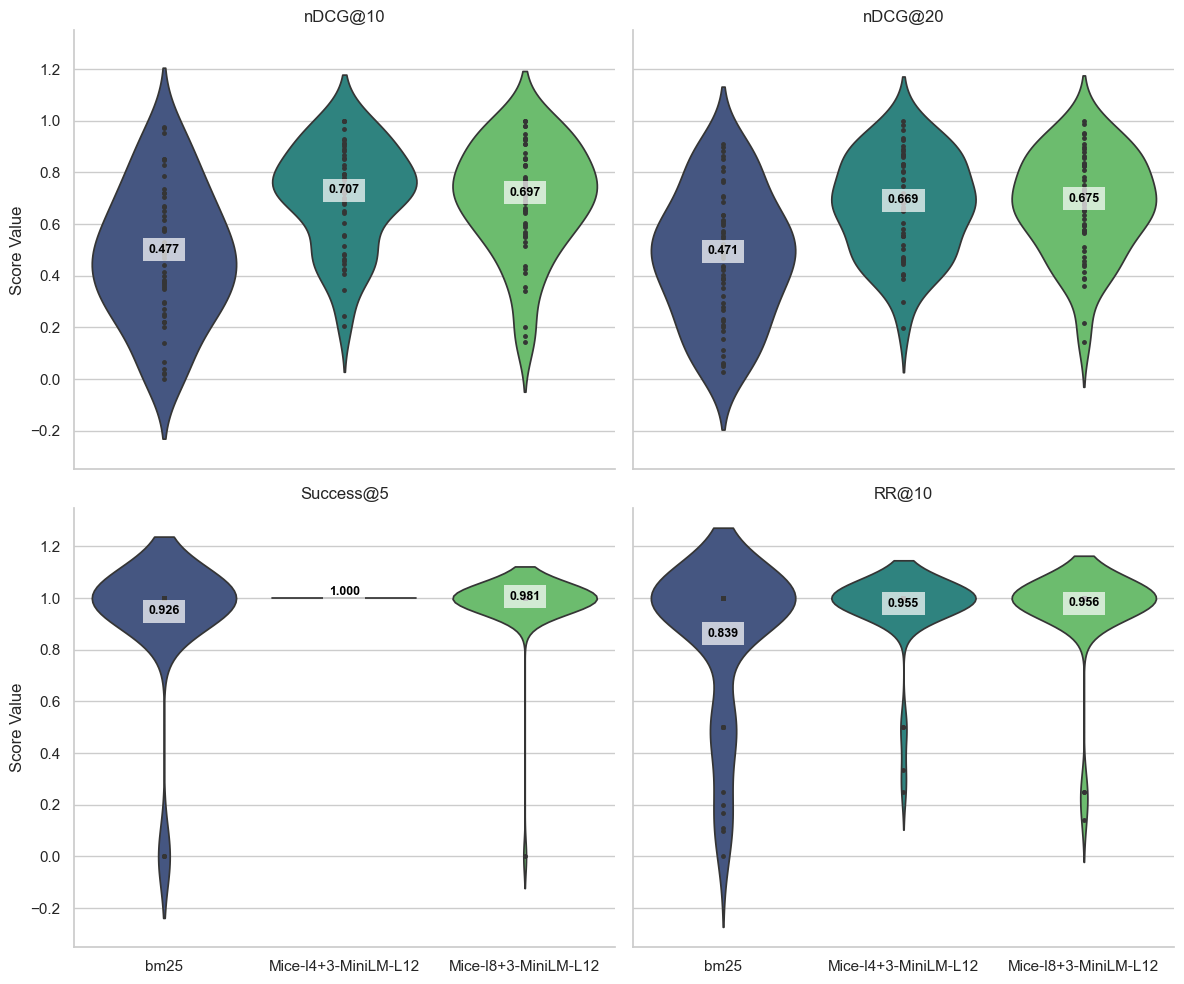

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_comparison(runs_per_model, dataset, models):
    all_data = []

    # 1. Combine data
    for model_name in models:
        df = runs_per_model[model_name][dataset].copy()
        df['Model'] = model_name
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)

    # 2. Plotting with Deprecation Fixes
    sns.set_theme(style="whitegrid")
    
    g = sns.catplot(
        data=combined_df, 
        x='Model', 
        y='Score', 
        hue='Model',       # Fix: Assign x to hue
        col='Metric', 
        kind='violin', 
        inner='points',
        palette='viridis',
        legend=False,      # Fix: Remove redundant legend
        col_wrap=2, 
        height=5, 
        aspect=1.2,
        sharey=True
    )

    # 4. Overlay Averages
    axes = g.axes.flatten()
    metrics = combined_df['Metric'].unique()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_data = combined_df[combined_df['Metric'] == metric]
        means = metric_data.groupby('Model', sort=False)['Score'].mean()
        
        for j, model_name in enumerate(models):
            avg_val = means[model_name]
            ax.text(j, avg_val, f'{avg_val:.3f}', 
                    color='black', ha='center', va='bottom', 
                    fontweight='bold', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.7, lw=0))

    g.set_axis_labels("", "Score Value")
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()

# Usage:
for dataset in datasets:
    print(f"distribution for {dataset}")
    plot_model_comparison(runs_per_model, dataset, models)

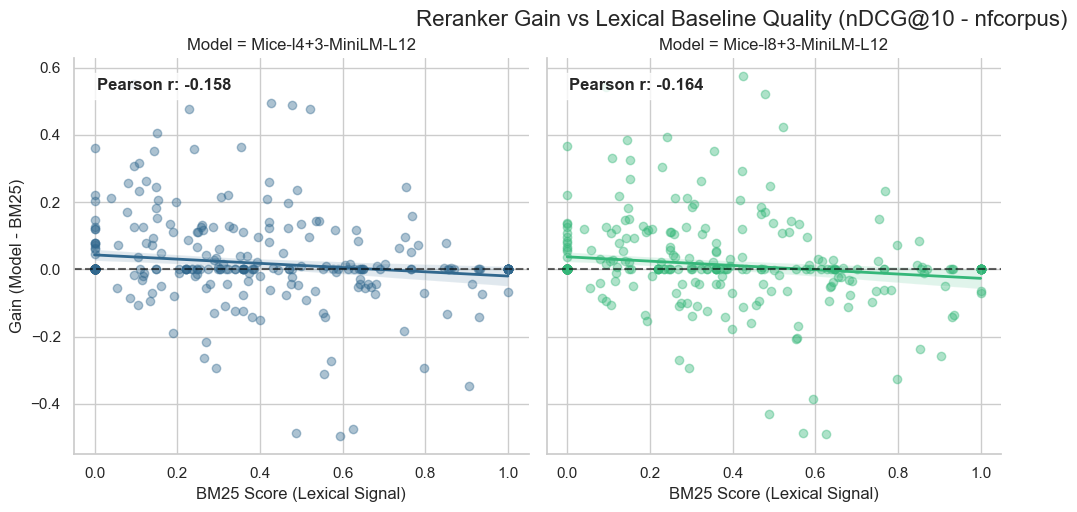

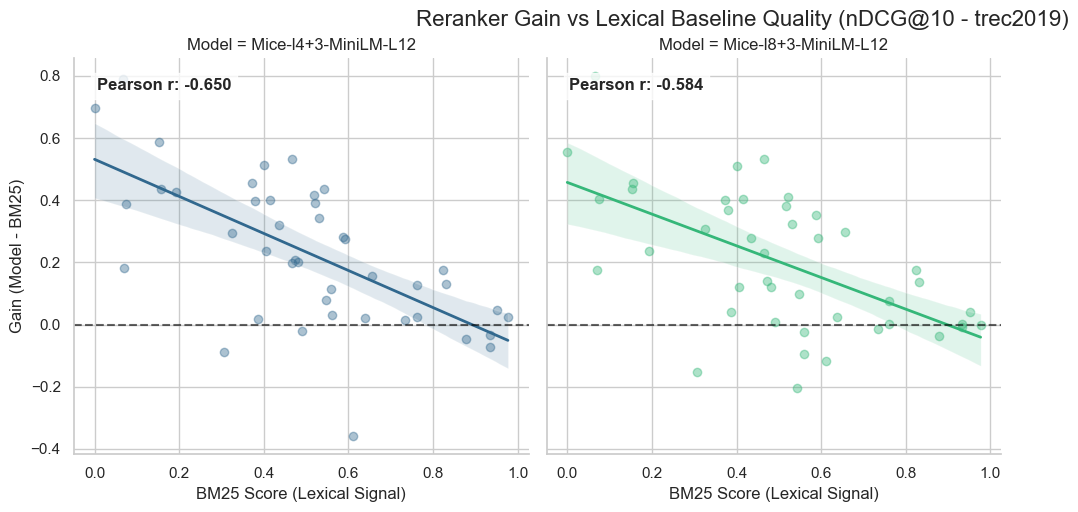

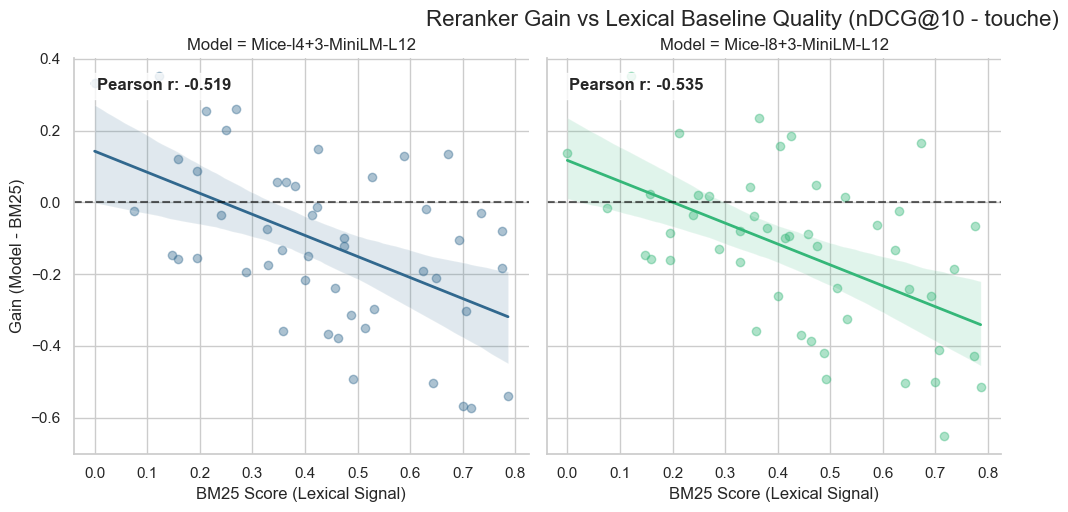

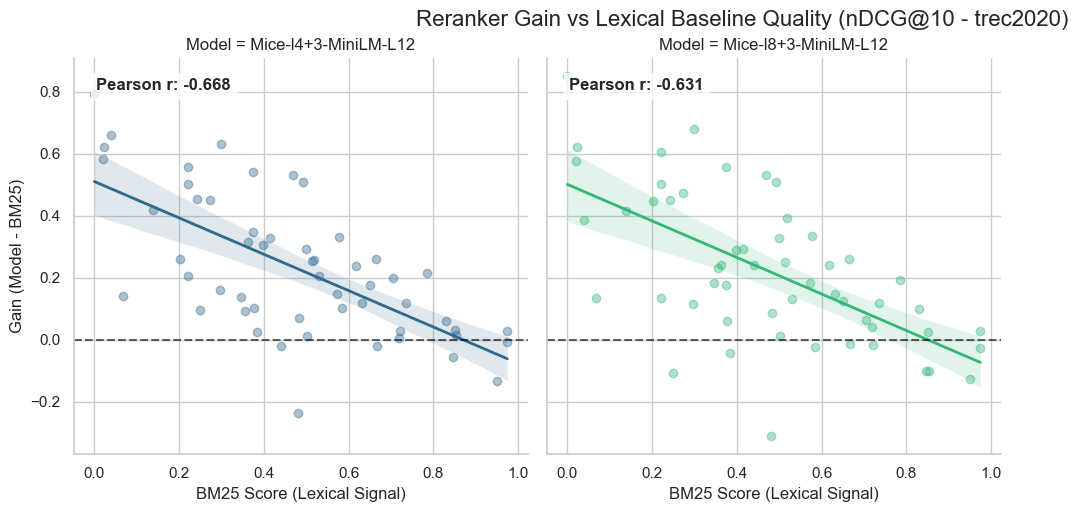

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_all_lexical_dependencies(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Build a combined dataframe for all models
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Delta': df_model['Score'] - df_bm25['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Use lmplot for side-by-side regression analysis
    sns.set_theme(style="whitegrid")
    g = sns.lmplot(
        data=combined_df, 
        x='BM25 Score', 
        y='Delta', 
        col='Model', 
        hue='Model',
        palette='viridis',
        scatter_kws={'alpha': 0.4},
        line_kws={'lw': 2},
        height=5, 
        aspect=1.0,
        col_wrap=3
    )

    # 3. Add baseline and Correlation coefficients
    for model_name, ax in g.axes_dict.items():
        # Draw baseline at 0
        ax.axhline(0, color='black', linestyle='--', alpha=0.6)
        
        # Calculate correlation for this specific model
        subset = combined_df[combined_df['Model'] == model_name]
        # Drop NaNs if any exist to prevent correlation errors
        subset = subset.dropna(subset=['BM25 Score', 'Delta'])
        
        corr, _ = stats.pearsonr(subset['BM25 Score'], subset['Delta'])
        
        # Display correlation in the plot
        ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    g.set_axis_labels("BM25 Score (Lexical Signal)", "Gain (Model - BM25)")
    g.fig.suptitle(f'Reranker Gain vs Lexical Baseline Quality ({metric} - {dataset})', y=1.02, fontsize=16)
    
    plt.show()

# Execution
for dataset in datasets:
    plot_all_lexical_dependencies(runs_per_model, dataset, models)

nfcorpus


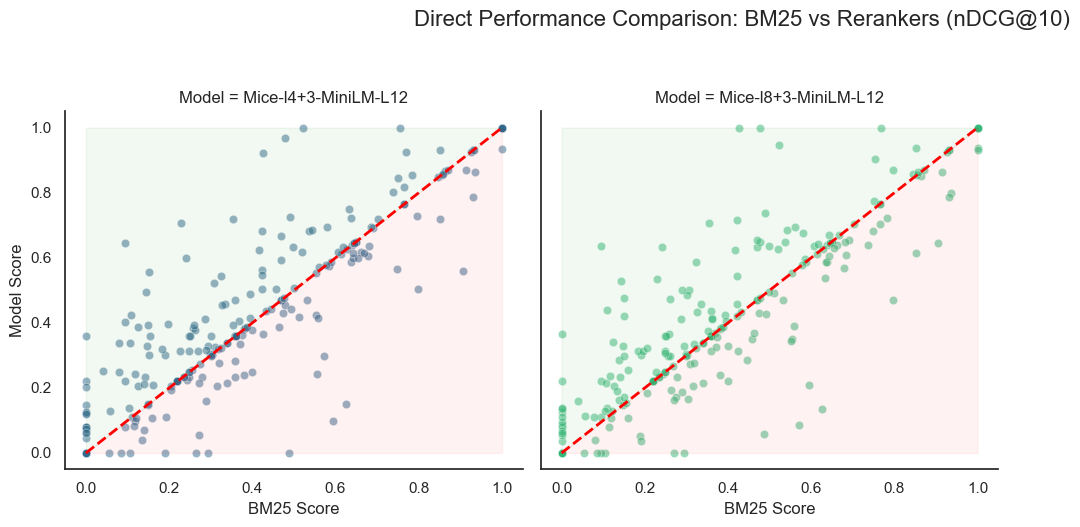

trec2019


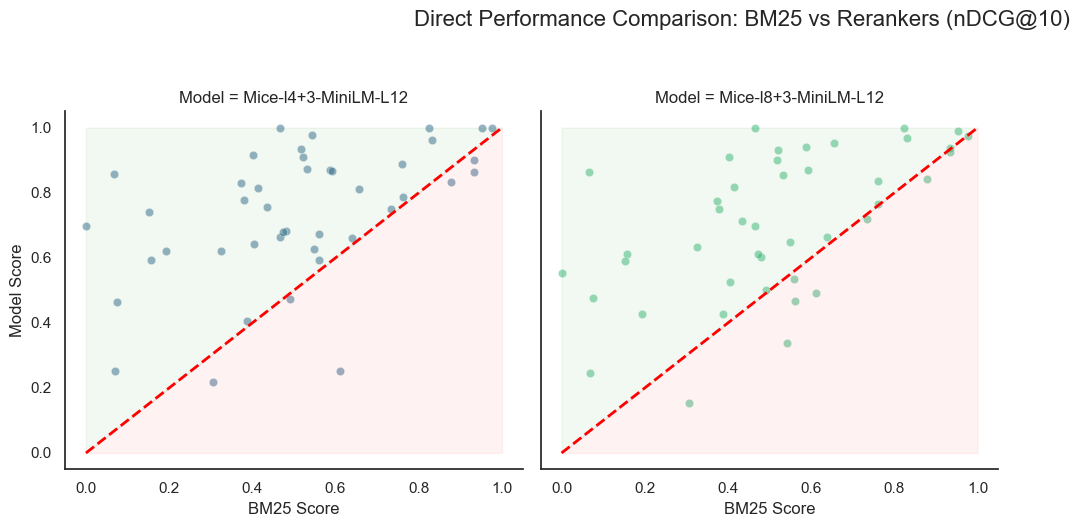

touche


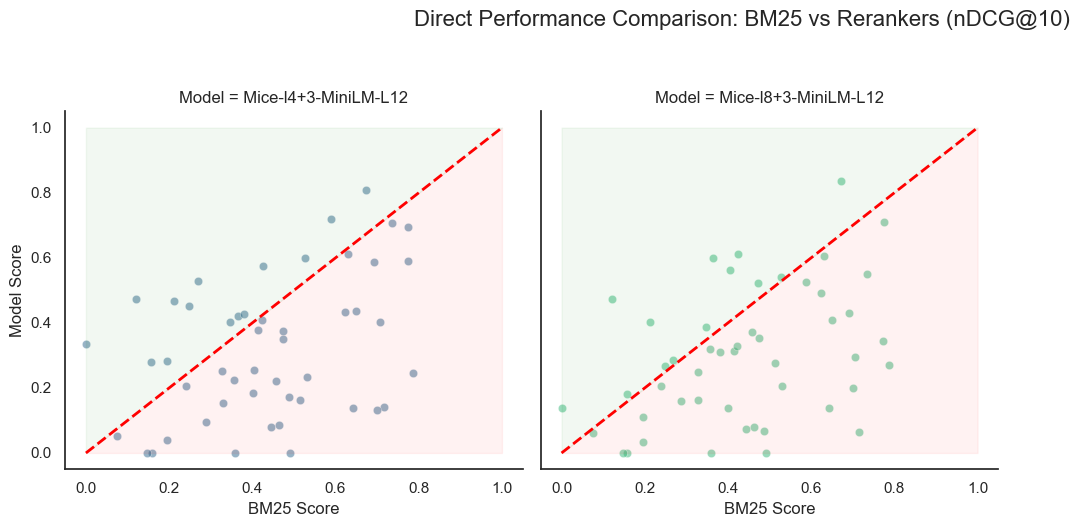

trec2020


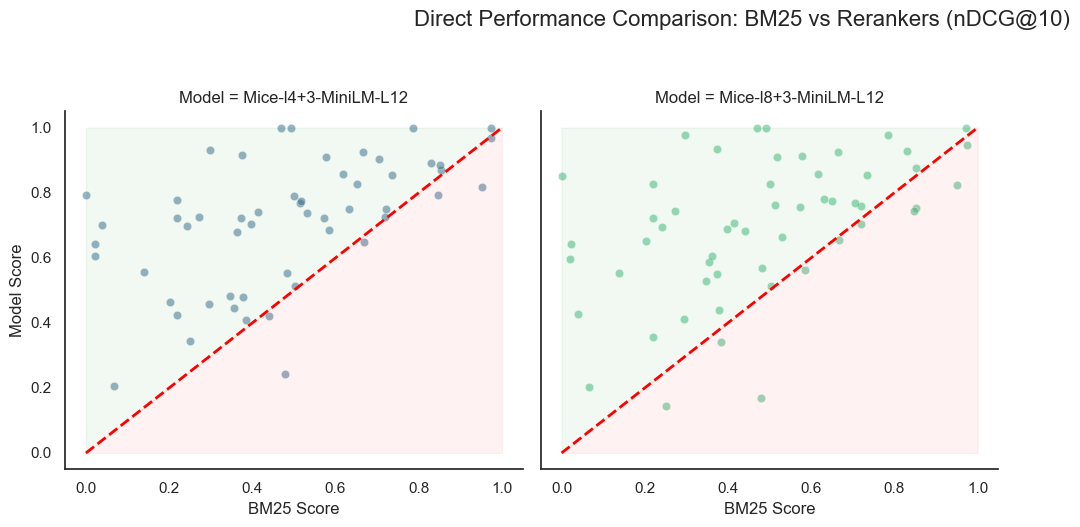

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bm25_vs_model_direct(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Get BM25 scores as the anchor
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Model Score': df_model['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Plotting
    sns.set_theme(style="white")
    g = sns.FacetGrid(combined_df, col="Model", hue="Model", 
                      palette='viridis', height=5, aspect=1, col_wrap=3)

    # Use regplot but disable the regression line if you just want the raw scatter, 
    # or keep it to see the general trend.
    g.map(sns.scatterplot, 'BM25 Score', 'Model Score', alpha=0.5)

    # 3. Add the Identity Line (y=x)
    for ax in g.axes.flatten():
        # Draw a 45-degree dashed line from (0,0) to (1,1)
        ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Identity (y=x)')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        
        # Optional: Count how many queries are above/below the line
        # This gives a quick "Win Rate" visual
        ax.fill_between([0, 1], [0, 1], 1, color='green', alpha=0.05) # "Model Win" zone
        ax.fill_between([0, 1], 0, [0, 1], color='red', alpha=0.05)   # "BM25 Win" zone

    g.set_axis_labels("BM25 Score", "Model Score")
    g.fig.suptitle(f'Direct Performance Comparison: BM25 vs Rerankers ({metric})', y=1.05, fontsize=16)
    
    plt.tight_layout()
    plt.show()

# plot_bm25_vs_model_direct(runs_per_model, "trec2020", models)
# Execution
for dataset in datasets:
    print(dataset)
    plot_bm25_vs_model_direct(runs_per_model, dataset, models)

# Ablations

## Booleans Ablation

In [ ]:
# Main table
import pandas as pd
from IPython.display import display, HTML

xps = [
    "train_mice_miniLM_bools",
]


def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None


raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)


# Define regex patterns for tags
tags = {
    "base": r"base=(.*)_global",
    "global_cls_token": r"global_cls_token=(.*)_mask_cls_to_doc",
    "mask_query_to_cls": r"mask_query_to_cls=(.*)_loss",
    "mask_cls_to_doc": r"mask_cls_to_doc=(.*)_mask",
}

# rm row without "scorer" tag
df = df[df["scorer"].notna()]
# Split "scorer" into separate columns using the regex patterns
for tag_name, pattern in tags.items():
    df[tag_name] = df["scorer"].apply(lambda x: get_tag(x, pattern))


# Ensure the boolean columns are boolean type
bool_cols = ["global_cls_token", "mask_query_to_cls", "mask_cls_to_doc"]
for col in bool_cols:
    df[col] = df[col].map({"True": True, "False": False})

datasets = list(df["dataset"].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
# print(f"unique losses : {list(df["loss"].unique())}")
# print(f"Backbones : {list(df["base"].unique())}")


display(HTML(df.iloc[0:5].to_html()))

9 unique datasets : ['Mean In Domain', 'fiqa', 'mean', 'msmarco_dev', 'nfcorpus', 'scifact', 'touche', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,first_stage,scorer,base,global_cls_token,mask_query_to_cls,mask_cls_to_doc
3,Mean In Domain,0.767267,2.837472e-05,0.842783,2.380488e-05,0.626333,4.908775e-06,0.612717,1.168059e-05,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=False_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,False,False
4,Mean In Domain,0.768283,1.560529e-06,0.846000,0.000000e+00,0.626450,9.338594e-07,0.613767,3.555358e-06,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=False_mask_query_to_cls=True_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,True,False
5,Mean In Domain,0.758600,4.999275e-07,0.843983,1.027278e-06,0.619367,1.494240e-05,0.608267,1.351999e-05,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=True_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,False,True
6,Mean In Domain,0.759467,1.682005e-05,0.837083,5.570655e-10,0.617517,3.466987e-06,0.603983,2.800545e-06,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=True_mask_query_to_cls=True_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,True,True
7,Mean In Domain,0.758700,5.780196e-06,0.838750,3.472464e-07,0.624617,9.392436e-08,0.613217,7.605629e-07,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=True_mask_cls_to_doc=False_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,True,False,False


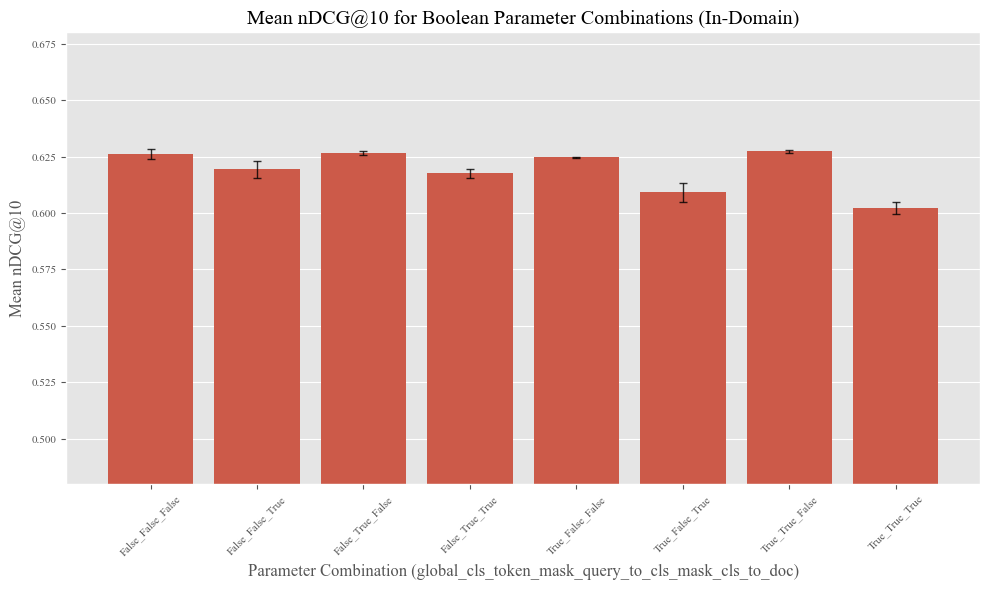

,global_cls_token,mask_query_to_cls,mask_cls_to_doc,mean_nDCG,mean_var,std_nDCG,combination
0,False,False,False,0.626333,4.908775e-06,0.002216,False_False_False
1,False,False,True,0.619367,1.494240e-05,0.003866,False_False_True
2,False,True,False,0.626450,9.338594e-07,0.000966,False_True_False
3,False,True,True,0.617517,3.466987e-06,0.001862,False_True_True
4,True,False,False,0.624617,9.392436e-08,0.000306,True_False_False
5,True,False,True,0.609117,1.820036e-05,0.004266,True_False_True
6,True,True,False,0.627283,5.338608e-07,0.000731,True_True_False
7,True,True,True,0.602150,6.600400e-06,0.002569,True_True_True


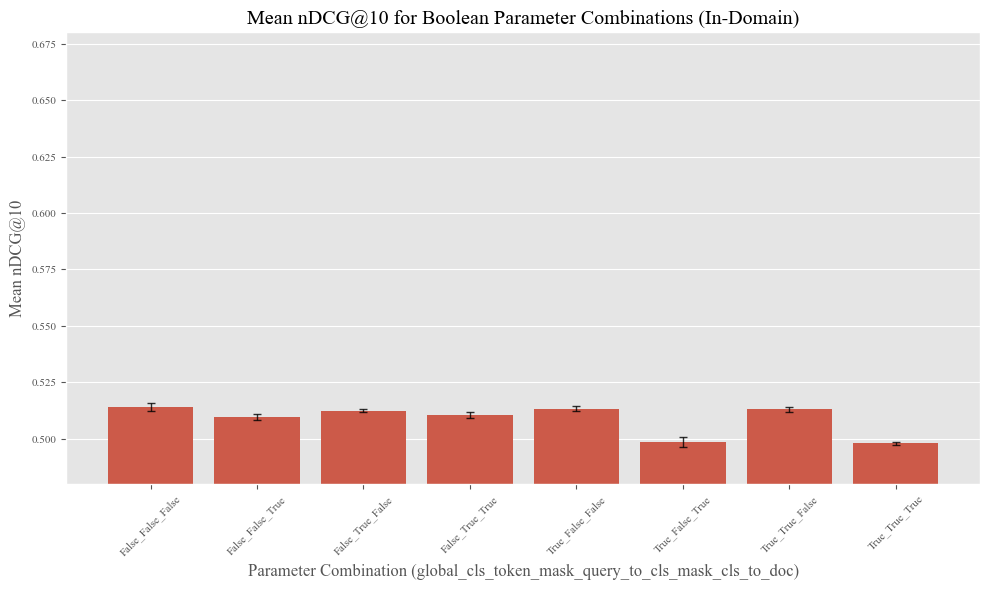

,global_cls_token,mask_query_to_cls,mask_cls_to_doc,mean_nDCG,mean_var,std_nDCG,combination
0,False,False,False,0.514000,2.948883e-06,0.001717,False_False_False
1,False,False,True,0.509779,2.086638e-06,0.001445,False_False_True
2,False,True,False,0.512550,2.449979e-07,0.000495,False_True_False
3,False,True,True,0.510393,1.751026e-06,0.001323,False_True_True
4,True,False,False,0.513407,1.594301e-06,0.001263,True_False_False
5,True,False,True,0.498457,5.028981e-06,0.002243,True_False_True
6,True,True,False,0.513157,1.103660e-06,0.001051,True_True_False
7,True,True,True,0.498000,4.718444e-07,0.000687,True_True_True


In [ ]:
# Plot in-domain nDCG@10_mean for each combination of boolean params

import matplotlib.pyplot as plt

for dataset in ["Mean In Domain", "mean"]:
    # Filter for in-domain dataset (assuming msmarco_dev is in-domain)
    in_domain_df = df[df["dataset"] == dataset].copy()

    # Group by the boolean combinations and compute mean of nDCG@10_mean and mean of nDCG@10_var
    grouped = (
        in_domain_df.groupby(bool_cols)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )

    # Compute std as sqrt of mean variance
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    # Create a combination label
    grouped["combination"] = grouped[bool_cols].astype(str).agg("_".join, axis=1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(data=grouped, x="combination", y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title("Mean nDCG@10 for Boolean Parameter Combinations (In-Domain)")
    ax.set_xlabel(
        "Parameter Combination (global_cls_token_mask_query_to_cls_mask_cls_to_doc)"
    )
    ax.set_ylabel("Mean nDCG@10")
    plt.xticks(rotation=45)
    plt.ylim(0.48, 0.68)
    plt.tight_layout()
    plt.show()

    # Display the grouped data
    display(grouped)

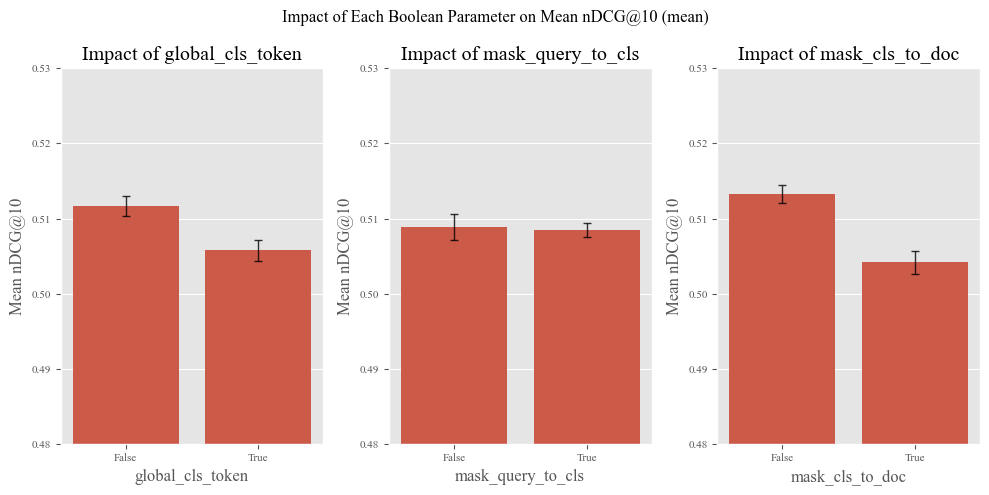

In [ ]:
# Plot impact of each boolean parameter separately

# Create subplots for each boolean parameter
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(
    "Impact of Each Boolean Parameter on Mean nDCG@10 ({dataset})".format(
        dataset=dataset
    )
)

grouped_dfs = []
for ax, param in zip(axes, bool_cols):
    grouped = (
        in_domain_df.groupby(param)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    sns.barplot(data=grouped, x=param, y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title(f"Impact of {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean nDCG@10")
    ax.set_ylim(0.48, 0.53)

    grouped_dfs.append(grouped)

plt.tight_layout()
plt.show()

## Mice MiniLM X+3 - Vanilla vs Inverted

In [35]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Inverted Cross-Self Attn",
    "train_mice_miniLM_lX+3_vanilla": "Vanilla Self-Cross Attn",
}


def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    xp_path = xps_root / xp / "20260425_161300" #
    if 'vanilla' in xp: 
        xp_path = get_last_xp(xps_root / xp)
    else:
        xp_path = xps_root / xp / "20260425_161300" #
        xp_path = get_last_xp(xps_root / xp)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', 'current', 'lock']
Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3/20260513_093201
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
2,In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN
3,In Domain,0.7280777,1.4114847e-06,0.8224667,1.3663354e-05,0.55876666,6.601004e-06,0.5579445,1.0670453e-06,microsoft/MiniLM-L12-H384-uncased,bm25,0
4,In Domain,0.7379778,1.9640476e-05,0.82625556,2.223799e-06,0.58382225,9.971361e-06,0.5800333,4.407645e-06,microsoft/MiniLM-L12-H384-uncased,bm25,1
5,In Domain,0.75412226,3.973603e-06,0.84076667,6.300482e-07,0.60194445,1.1077915e-05,0.59511113,7.071646e-06,microsoft/MiniLM-L12-H384-uncased,bm25,2
6,In Domain,0.7584222,9.2294285e-06,0.83955556,1.4446058e-05,0.61396664,1.1811496e-06,0.60326666,1.8777122e-07,microsoft/MiniLM-L12-H384-uncased,bm25,3


Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_vanilla: ['20260421_083259', 'current', 'dry-run']
Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_vanilla: ['20260421_083259', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_vanilla/20260421_083259
9 unique datasets : ['Mean In Domain', 'fiqa', 'mean', 'msmarco_dev', 'nfcorpus', 'scifact', 'touche', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,loss,n_contextualization_layers
2,Mean In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN,NaN
3,Mean In Domain,0.72519994,1.2500125e-05,0.8211833,8.449705e-07,0.55355,8.449705e-07,0.5492667,1.8688369e-06,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,0
4,Mean In Domain,0.74445,3.827393e-06,0.83265,5.570655e-10,0.5837167,8.133864e-06,0.5800834,6.6006164e-06,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,1
5,Mean In Domain,0.7535167,0.00019933439,0.8358167,4.640026e-05,0.5945,5.7602574e-05,0.5893,6.346936e-05,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,2
6,Mean In Domain,0.75285006,6.1252595e-06,0.83924997,5.894242e-06,0.61195,6.1249466e-06,0.5997667,3.919966e-06,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,3


No data found for dataset: Mean In Domain


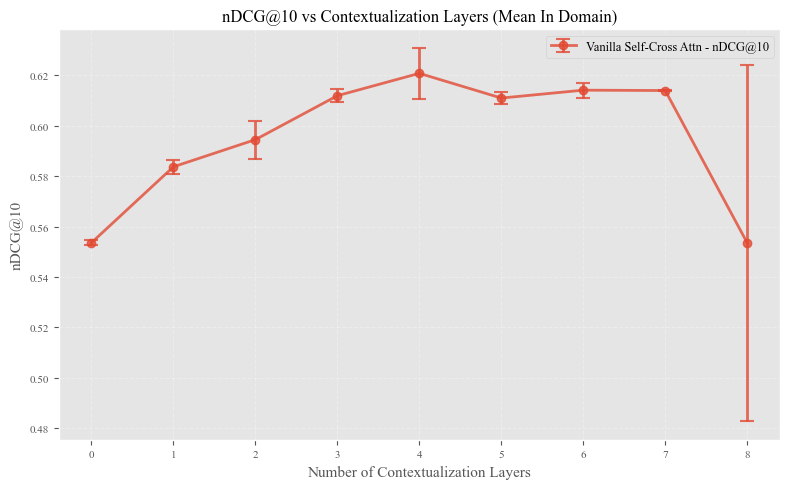


Aggregated nDCG@10 Statistics by Contextualization Layers (Mean In Domain):


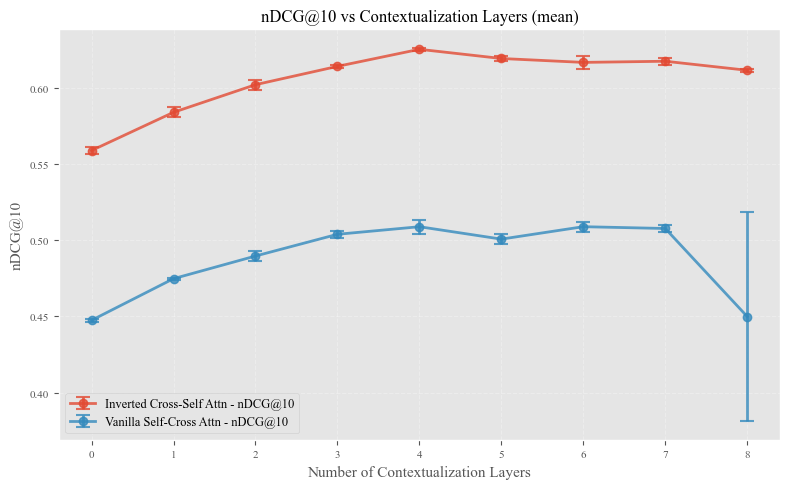


Aggregated nDCG@10 Statistics by Contextualization Layers (mean):


In [ ]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"

# Plot for each dataset
for dataset_name in ["Mean In Domain", "mean"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(8, 5))

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")

        ax.errorbar(
            grouped["n_contextualization_layers"],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=6,
            linewidth=2,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]} - {metric}"
        )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}_vs_vanilla.pdf")
    plt.show()
    # Display grouped results
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
        # display(grouped)